## Projeto Avaliativo - Análise Preditiva (SCTEC)

### Fase 1: Análise Exploratória (EDA)

In [35]:
# Importando as bibliotecas essenciais para o projeto
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
# Carregando o arquivo CSV e transformando em um DataFrame
df = pd.read_csv('Data/manutencao_preditiva.csv')

# Exibindo as 5 primeiras linhas para conhecermos as variáveis
df.head()

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,4,L47183,L,NaN,NaN,NaN,NaN,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0


In [37]:
# 1. Mostra as dimnesões (Linhas, Colunas)
print("Dimensões do dataset:", df.shape)
print("-" * 50)

# 2. Mostra os tipos de dados e se há valores nulos gerais
print("Informações sobre os tipos de dados e valores nulos gerais:")
print(df.info())
print("-" * 50)

# 3. Gera o resumo estatístico descritivo
print("Resumo estatístico das colunas numéricas:")
print(df.describe())





Dimensões do dataset: (10000, 14)
--------------------------------------------------
Informações sobre os tipos de dados e valores nulos gerais:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   udi                      10000 non-null  int64  
 1   id_produto               10000 non-null  str    
 2   tipo                     10000 non-null  str    
 3   temperatura_ar_k         9500 non-null   float64
 4   temperatura_processo_k   9500 non-null   float64
 5   velocidade_rotacao_rpm   9500 non-null   float64
 6   torque_nm                9500 non-null   float64
 7   desgaste_ferramenta_min  10000 non-null  int64  
 8   falha_maquina            10000 non-null  int64  
 9   falha_twf                10000 non-null  int64  
 10  falha_hdf                10000 non-null  int64  
 11  falha_pwf                10000 non-null  int64  
 1

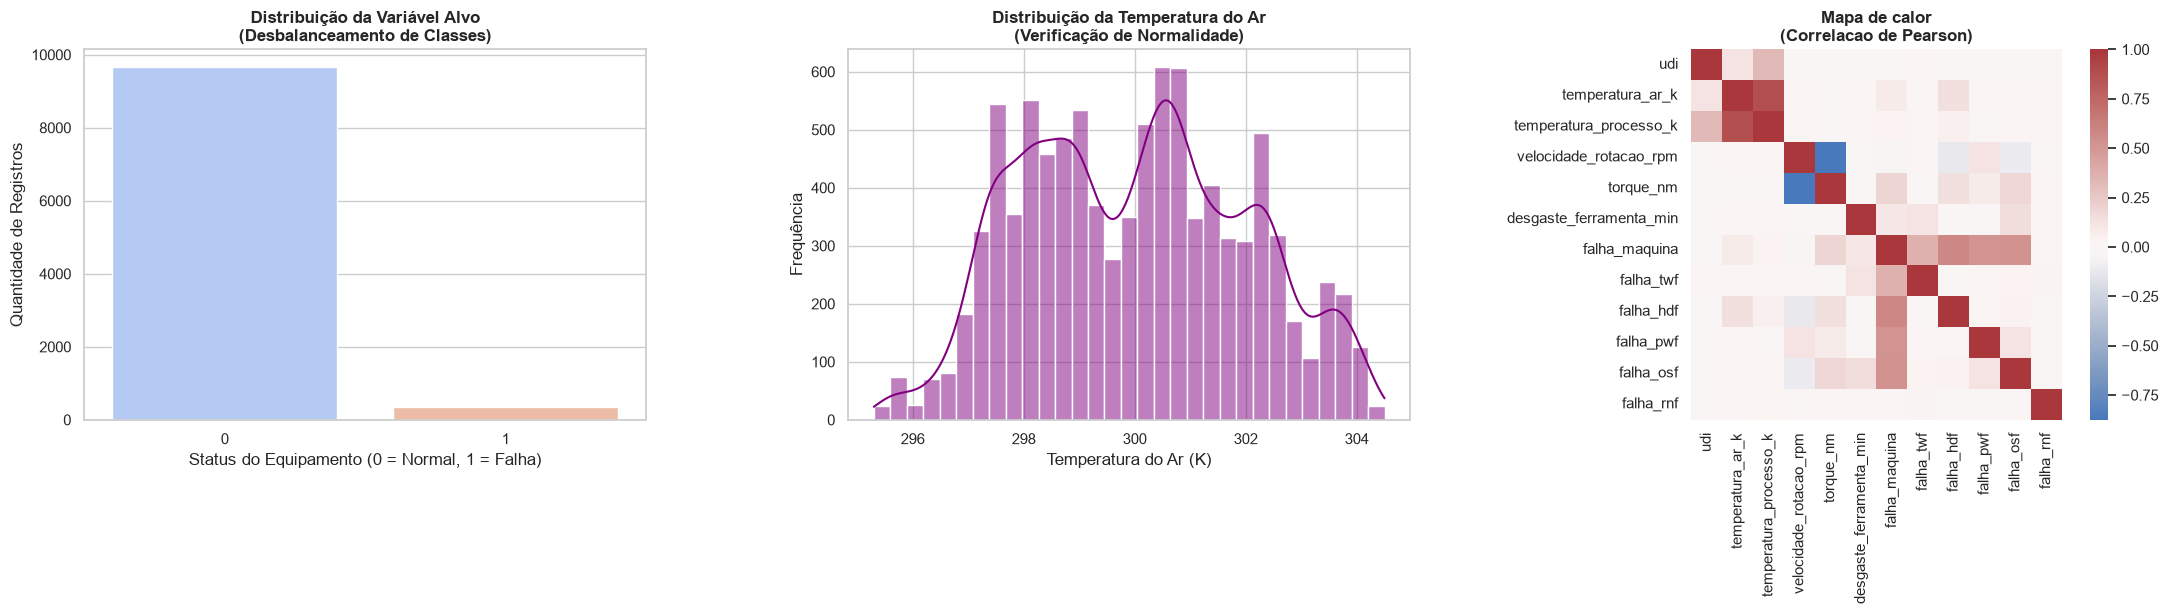

In [38]:
from matplotlib import legend
# Configurando o estilo visual dos gráficos
sns.set_theme(style="whitegrid")

# Criando uma área de desenho para acomodar os 3 gráficos lado a lado
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# 1. Gráfico de barras: Verificando o desbalanceamento da variável alvo
sns.countplot(ax=axes[0], x='falha_maquina', data=df, hue='falha_maquina', palette='coolwarm', legend=False)
axes[0].set_title('Distribuição da Variável Alvo\n(Desbalanceamento de Classes)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Status do Equipamento (0 = Normal, 1 = Falha)')
axes[0].set_ylabel('Quantidade de Registros')

# 2. Histograma: analisando a distribuição de uma variável preditora
sns.histplot(ax=axes[1], x='temperatura_ar_k', data=df, kde=True, color='purple')
axes[1].set_title('Distribuição da Temperatura do Ar\n(Verificação de Normalidade)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Temperatura do Ar (K)')
axes[1].set_ylabel('Frequência')

# 3. Mapa de calor: Analisando a Correlação de Pearson entre as variáveis
# Filtrando apenas as colunas numéricas para o cálculo
colunas_num = df.select_dtypes(include=['int64', 'float64']).columns
correlacao = df[colunas_num].corr()

sns.heatmap(ax=axes[2], data=correlacao, annot=False, cmap='vlag', center=0, square=True)
axes[2].set_title('Mapa de calor\n(Correlacao de Pearson)', fontsize=12, fontweight='bold')

# Ajustando o espaçamento para não cortar nenhuma informação
plt.tight_layout()
plt.show()

**Análise dos Padrões e Estratégia de Modelagem:**

**Desbalanceamento de Classes**: O gráfico de barras evidencia um severo desbalanceamento na variável alvo (**falha_maquina**). Isso direciona a estratégia de modelagem a adotar técnicas de controle ou métricas de avaliação cuidadosas para evitar o overfitting (sobreajuste) na classe majoritária.

**Critério de Imputação**: O histograma demonstra que variáveis como a temperatura do ar não seguem uma distribuição normal perfeita, apresentando assimetrias e múltiplos picos. Portanto, a estratégia para a Fase 2 será utilizar a Mediana para a imputação de dados ausentes, por ser uma medida estatística mais robusta a essas variações.

**Multicolinearidade**: O mapa de calor revela forte correlação positiva (tons quentes) entre as temperaturas do ar e do processo. Essa redundância de informações guiará a seleção de características (feature engineering) para evitar ruídos no modelo preditivo.

### Fase 2: Limpeza e Tratamento de Dados (Data Prep)

In [ ]:
# 1. Identificando a quantidade de linhas duplicadas
duplicadas = df.duplicated().sum()
print(f"Quantidade de linhas duplicadas encontradas: {duplicadas}")
print("-" * 50)

# 2. Removendo as linhas duplicadas  (caso existam)
# O comando inplace=True aplica a limpeza diretamente na nossa variável 'df'
if duplicadas > 0:
  df.drop_duplicates(inplace=True)
  print("Limpeza concluída! Linhas duplicadas foram removidas.")
else:
  print("Nenhuma linha duplicada encontrada. A base já estava limpa neste aspecto")

print("-" * 50)
# 3. Conferindo o novo tamanho do dataset após a limpeza
print("Novas dimensões do dataset após limpeza:", df.shape)
#

Quantidade de linhas duplicadas encontradas: 0
--------------------------------------------------
Nenhuma linha duplicada encontrada. A base já estava limpa neste aspecto
--------------------------------------------------
Novas dimensões do dataset após limpeza: (10000, 14)


In [40]:
# O Código de Imputação
# 1. Verificando a quantidade de dados nulos por coluna antes da imputação
print("Valores nulos ANTES da imputação:")
print(df.isnull().sum())
print("-" * 50)

# 2. Lista das colunas que identificamos com dados ausentes
colunas_com_nulos = [
    'temperatura_ar_k',
    'temperatura_processo_k',
    'velocidade_rotacao_rpm',
    'torque_nm'
]

# 3. Aplicando a imputação pela Mediana usando um laço de repetição (for)
for coluna in colunas_com_nulos:
  # Calcula a mediana da coluna específica
  mediana_coluna = df[coluna].median()
  # Substitui os nulos (NaN) pela mediana calculada
  df[coluna] = df[coluna].fillna(mediana_coluna)

# 4. Verificando se restaram dados nulos após a imputação
print("Valores nulos APÓS a imputação:")
print(df.isnull().sum())

Valores nulos ANTES da imputação:
udi                          0
id_produto                   0
tipo                         0
temperatura_ar_k           500
temperatura_processo_k     500
velocidade_rotacao_rpm     500
torque_nm                  500
desgaste_ferramenta_min      0
falha_maquina                0
falha_twf                    0
falha_hdf                    0
falha_pwf                    0
falha_osf                    0
falha_rnf                    0
dtype: int64
--------------------------------------------------
Valores nulos APÓS a imputação:
udi                        0
id_produto                 0
tipo                       0
temperatura_ar_k           0
temperatura_processo_k     0
velocidade_rotacao_rpm     0
torque_nm                  0
desgaste_ferramenta_min    0
falha_maquina              0
falha_twf                  0
falha_hdf                  0
falha_pwf                  0
falha_osf                  0
falha_rnf                  0
dtype: int64


**Justificativa da Estratégia de Imputação:**

A análise exploratória prévia, especialmente a observação do histograma, demonstrou que as variáveis numéricas dos sensores (como a temperatura do ar) não seguem uma distribuição normal perfeita. Por apresentarem assimetrias e picos irregulares, a utilização da Média para preenchimento poderia introduzir distorções nos dados da operação. Portanto, optou-se tecnicamente pela aplicação da Mediana para a imputação dos valores ausentes (NaN), por se tratar de uma medida de tendência central mais robusta e imune a deformações por valores atípicos.

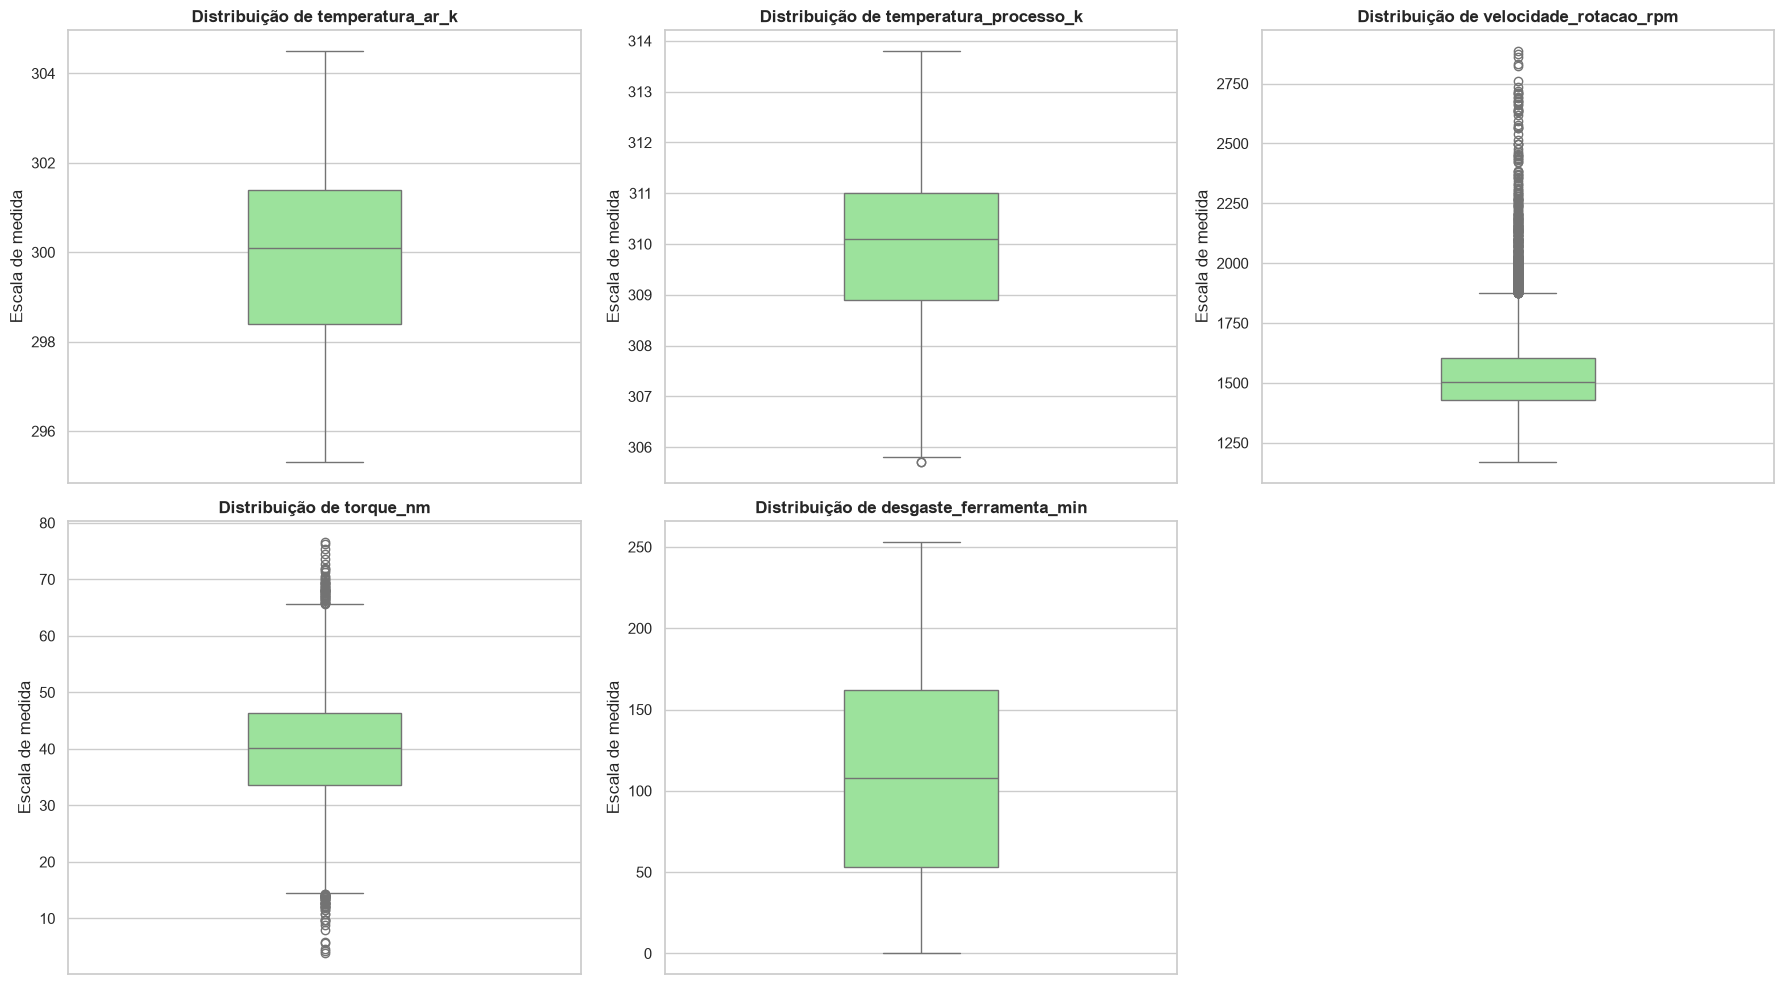

In [41]:
# Lista das variáveis explicativas contínuas para analisar a presença de outliers
variaveis_sensores = [
    'temperatura_ar_k',
    'temperatura_processo_k',
    'velocidade_rotacao_rpm',
    'torque_nm', 'desgaste_ferramenta_min'
]

# Criando uma janela de desenho com uma grade de 2 linhas e 3 colunas (total de 6 espaços)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten() # Achata a matriz de eixos para facilitar o mapeamento no laço de repetição

# Configurando o estilo visual dos gráficos
sns.set_theme(style="whitegrid")

# Loop para desenhar de forma automatizada o boxplot de cada sensor
for i, coluna in enumerate(variaveis_sensores):
  sns.boxplot(ax=axes[i], y=df[coluna], color='lightgreen', width=0.3)
  axes[i].set_title(f'Distribuição de {coluna}', fontsize=12, fontweight='bold')
  axes[i].set_ylabel('Escala de medida')
  axes[i].set_xlabel('')

# Como temos 5 variáveis e a grade possui 6 espaços, desativamos o último quadrante
axes[5].axis('off')

# Ajustando o layout para evitar sobreposições de títulos
plt.tight_layout()
plt.show()

**Análise de Outliers (Valores Discrepantes):**

Através da visualização dos gráficos de Boxplot, identificou-se a ausência de outliers nas variáveis de temperatura e desgaste da ferramenta. Em contrapartida, as variáveis **velocidade_rotacao_rpm** e **torque_nm** apresentaram forte presença de valores atípicos. No contexto de manutenção preditiva industrial, optou-se por não remover estes outliers, uma vez que picos operacionais de força e rotação são eventos mecânicos cruciais e contêm alto valor preditivo para antecipar as falhas dos equipamentos.

### Fase 3: Engenharia de Recursos (Feature Engineering)

**Criação de Nova Variável (Potência):**
De acordo com os requisitos do projeto, foi criada uma nova variável numérica designada **potencia**. Esta métrica resulta da multiplicação direta entre a **velocidade_rotacao_rpm** e o **torque_nm**. Fisicamente, a potência é um excelente indicador do nível de esforço e desgaste do equipamento. Como todos os valores nulos já foram devidamente tratados na fase de preparação de dados (imputação pela mediana), a operação matemática foi realizada com segurança, garantindo a integridade da nova coluna.

In [ ]:
# Fase 3: Engenharia de Atributos (Feature Engineering)
# Criando a nova coluna 'potencia' com base na velocidade e no torque
df['potencia'] = df['velocidade_rotacao_rpm'] * df['torque_nm']

# Exibindo as primeiras 5 linhas mostrando apenas as colunas envolvidas para confirmar
print("Nova coluna criada com sucesso!")
df[['velocidade_rotacao_rpm', 'torque_nm', 'potencia']].head()

Nova coluna criada com sucesso!


,velocidade_rotacao_rpm,torque_nm,potencia
0,1551.0,42.8,66382.8
1,1408.0,46.3,65190.4
2,1498.0,49.4,74001.2
3,1504.0,40.1,60310.4
4,1408.0,40.0,56320.0


### Fase 4: Divisão e Balanceamento dos Dados

**Separação entre Variáveis Preditoras (X) e Alvo (y):**

Nesta etapa, isolamos a variável que queremos prever (**falha_maquina**) do restante do conjunto de dados. Identificadores inúteis e colunas de falhas específicas foram removidos para evitar o vazamento de dados (*Data Leakage*). Em seguida, os dados foram divididos em 80% para treino e 20% para teste, utilizando o parâmetro **stratify** para garantir que a proporção de máquinas com falha seja idêntica em ambos os conjuntos.

In [ ]:
# Fase 4: Divisão e balanceamento dos dados
from sklearn.model_selection import train_test_split

# 1. Separando X (preditoras) e y (alvo)
y = df['falha_maquina']

# Criando X: Removemos o alvo (y), os identificadores inúteis e as colunas de vazamento de dados
colunas_para_remover = [
    'falha_maquina', # O nosso alvo
    'udi', # Apenas um número de linha
    'id_produto', # Apenas um código de identificação
    'falha_twf', 'falha_hdf', 'falha_pwf', 'falha_osf', 'falha_rnf' # Vazamento de dados

]

# O parâmetro axis=1 indica que estamos removendo colunas (e não linhas)
X = df.drop(colunas_para_remover, axis=1)

# Se houver colunas do tipo 'object' (texto) restantes, precisamos convertê-las (como a coluna 'tipo' que tem L, M, H)
# A função get_dummies transforma essas categorias em colunas numéricas 0 e 1
X = pd.get_dummies(X, drop_first=True)

# 2. Dividindo os dados em treino (80%) e teste (20%)
# O stratify=y garante que a proporção de máquinas quebradas seja igual no treino e no teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

print("---Dimensões dos dados de treino---")
print(f"Preditoras (X_train): {X_train.shape}")
print(f"Alvo (y_train: {y_train.shape}")
print("\n---Dimensões dos dados de teste---")
print(f"Preditoras (x_test): {X_test.shape}")
print(f"Alvo (y_test: {y_test.shape}")


---Dimensões dos dados de treino---
Preditoras (X_train): (8000, 8)
Alvo (y_train: (8000,)

---Dimensões dos dados de teste---
Preditoras (x_test): (2000, 8)
Alvo (y_test: (2000,)


**Balanceamento de Dados com SMOTE:**

Devido ao forte desbalanceamento identificado na Análise Exploratória (Fase 1), foi aplicada a técnica SMOTE (Synthetic Minority Over-sampling Technique). Esta técnica gera exemplos sintéticos da classe minoritária (máquinas com falha) para equilibrar o conjunto, evitando que o modelo crie um viés de previsão voltado apenas para a classe majoritária.

Para garantir a integridade da avaliação e evitar o *Data Leakage* (vazamento de dados), o rebalanceamento foi aplicado **exclusivamente aos dados de treino**. O conjunto de teste foi mantido com sua distribuição original, garantindo que o modelo seja testado em um cenário idêntico ao mundo real.

In [44]:
from imblearn.over_sampling import SMOTE

# Inicializando a ferramenta SMOTE
smote = SMOTE(random_state=42)

# Aplicando o balanceamento EXCLUSIVAMENTE nos dados de treino
X_train_balanceado, y_train_balanceado = smote.fit_resample(X_train, y_train)

# Verificando a mágica acontecer
print("---Quantidade de classes ANTES do SMOTE (Treino)---")
print(y_train.value_counts())
print("\n---Quantidade de classes APÓS o SMOTE (Treino)---")
print(y_train_balanceado.value_counts())



---Quantidade de classes ANTES do SMOTE (Treino)---
falha_maquina
0    7729
1     271
Name: count, dtype: int64

---Quantidade de classes APÓS o SMOTE (Treino)---
falha_maquina
0    7729
1    7729
Name: count, dtype: int64


### Fase 5: Escalonamento de Variáveis (StandardScaler)

**Justificativa do Escalonamento:**

Foi aplicado o `StandardScaler` exclusivamente nas variáveis contínuas destinadas ao treinamento do modelo KNN, utilizando `fit_transform` nos dados de treino e apenas `transform` nos dados de teste para evitar o vazamento de informações da distribuição de teste.

Os dados originais (sem escalonamento) foram mantidos em variáveis separadas para o treinamento do modelo de Árvore de Decisão. Algoritmos baseados em árvores particionam os dados através de regras de corte binárias em cada nó, não utilizando cálculos de distância euclidiana. Por esse motivo, eles são estruturalmente imunes à escala ou magnitude dos atributos, tornando o escalonamento desnecessário para este modelo específico.

In [ ]:
# Fase 5: Escalonamento de variáveis (StandardScaler)
from sklearn.preprocessing import StandardScaler

# 1. Separando as  colunas contínuas que precisam de escalonamento (excluindo as categorias tipo_L, tipo_M)
cols_continuas = [
    'temperatura_ar_k',
    'temperatura_processo_k',
    'velocidade_rotacao_rpm',
    'torque_nm', 'desgaste_ferramenta_min',
    'potencia'
]

# 2. Criando as cópias exclusivas para o modelo KNN
X_train_knn = X_train_balanceado.copy()
X_test_knn = X_test.copy()

# 3. Inicializando o StandardScaler
scaler = StandardScaler()

# 4. Aplicando fit_tranform APENAS no treino, e transform no teste (para evitar Data Leakage)
X_train_knn[cols_continuas] = scaler.fit_transform(X_train_knn[cols_continuas])
X_test_knn[cols_continuas] = scaler.transform(X_test_knn[cols_continuas])
print("---Escalonamento concluído---")
print("Dados para Árvore de Decisão: X_train_balanceado e X_test (Escala Original)")
print("Dados para KNN: X_train_knn e X_test_knn (Escala Padronizada)")

# Visualizando como ficaram os dados do KNN (valores agora orbitam em torno de 0)
X_train_knn[cols_continuas].head(3)




---Escalonamento concluído---
Dados para Árvore de Decisão: X_train_balanceado e X_test (Escala Original)
Dados para KNN: X_train_knn e X_test_knn (Escala Padronizada)


,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,potencia
0,-0.174305,-0.047064,-0.055385,-0.323475,-1.048131,-0.277696
1,-1.823727,-1.433132,-0.413819,0.121609,0.127521,0.033353
2,0.304559,1.107992,-0.557193,0.065091,0.202884,-0.171688


## Fase 6: Ajuste de Parâmetros e Combate ao Overfitting

In [ ]:
# Fase 6: Ajuste de parâmetros e combate ao overfitting
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

print("---Avaliação do modelo KNN (Dados Escalonados---)")
valores_k = [3, 5, 7]
for k in valores_k:
  # 1. Cria o modelo com o K atual
  knn = KNeighborsClassifier(n_neighbors=k)
  # 2. Treina o modelo usando os dados padronizados
  knn.fit(X_train_knn, y_train_balanceado)

  # 3. Calcula a acurácia no Treino e no Teste
  acc_train_knn = accuracy_score(y_train_balanceado, knn.predict(X_train_knn))
  acc_test_knn = accuracy_score(y_test, knn.predict(X_test_knn))

  print(f"KNN (K={k: <2}) -> Treino: {acc_train_knn:.4f} | Teste: {acc_test_knn:.4f}")

print("\n---Avaliação do modelo Árvore de Decisão (Dados Originais---)")
valores_profundidade = [3, 5, None]
for depth in valores_profundidade:
  # 1. Cria a Árvore com a profundidade atual
  arvore = DecisionTreeClassifier(max_depth=depth, random_state=42)
  # 2. Treina o modelo usando os dados originais (sem escala)
  arvore.fit(X_train_balanceado, y_train_balanceado)

  # Calcula a acurácia no Treino e no Teste
  acc_train_arvore = accuracy_score(y_train_balanceado, arvore.predict(X_train_balanceado))
  acc_test_arvore = accuracy_score(y_test, arvore.predict(X_test))
  print(f"Árvore (max_depth={str(depth): <4}) -> Treino: {acc_train_arvore:.4f} | Test: {acc_test_arvore:.4f}")


---Avaliação do modelo KNN (Dados Escalonados---)
KNN (K=3 ) -> Treino: 0.9714 | Teste: 0.9140
KNN (K=5 ) -> Treino: 0.9609 | Teste: 0.9095
KNN (K=7 ) -> Treino: 0.9543 | Teste: 0.9015

---Avaliação do modelo Árvore de Decisão (Dados Originais---)
Árvore (max_depth=3   ) -> Treino: 0.8579 | Test: 0.8595
Árvore (max_depth=5   ) -> Treino: 0.9034 | Test: 0.9120
Árvore (max_depth=None) -> Treino: 0.9945 | Test: 0.9445


## Fase 7: Avaliação da Acurácia e Veredito Final

In [ ]:
# Fase 7: Avaliação da acurácia e veredito final
# Recriando os melhores modelos verdadeiros (considerando acurácia e estabilidade)
melhor_knn = KNeighborsClassifier(n_neighbors=3)
melhor_knn.fit(X_train_knn, y_train_balanceado)
acuracia_knn = accuracy_score(y_test, melhor_knn.predict(X_test_knn))

melhor_arvore = DecisionTreeClassifier(max_depth=5, random_state=42) # A profundidade 5 é a verdadeira vencedora!
melhor_arvore.fit(X_train_balanceado, y_train_balanceado)
acuracia_arvore = accuracy_score(y_test, melhor_arvore.predict(X_test))

print("---ACURÁCIA FINAL NOS DADOS DE TESTE---")
print(f"Melhor modelo KNN (K=3): {acuracia_knn * 100:.2f}%")
print(f"Melhor Árvore de Decisão Estável (max_depth=5): {acuracia_arvore * 100:.2f}%")



---ACURÁCIA FINAL NOS DADOS DE TESTE---
Melhor modelo KNN (K=3): 91.40%
Melhor Árvore de Decisão Estável (max_depth=5): 91.20%


**Veredito Final e Recomendação:**

Ao avaliarmos as métricas absolutas, o modelo de Árvore de Decisão sem limite de profundidade (`max_depth=None`) apresentou a maior taxa de acerto no teste (94,45%). No entanto, este modelo foi formalmente desclassificado de nossa recomendação técnica por apresentar um grave quadro de *overfitting* (tendo alcançado 99,45% no treino). Em um cenário de manutenção preditiva industrial, aprovar um modelo que "decora" o comportamento passado representa um risco operacional elevado, pois ele falhará ao tentar prever quebras com base em dados inéditos.

Excluindo o modelo sobreajustado, a disputa real pela estabilidade ocorreu entre o KNN (K=3), com **91,40%** de acurácia, e a Árvore de Decisão limitada (`max_depth=5`), com **91,20%**.

**Justificativa e Escolha:**
Apesar de o KNN apresentar uma vantagem matemática ínfima de 0,20% no teste final, ele ainda demonstrou leves sinais de instabilidade, com a taxa de treino ultrapassando os 97%. Em contrapartida, a Árvore de Decisão (`max_depth=5`) provou ser um modelo de consistência impecável, entregando 90,34% no treino e 91,20% no teste.

A recomendação oficial para implementação na empresa é a **Árvore de Decisão (max_depth=5)**. A escolha prioriza um sistema preditivo robusto, confiável e generalista em vez de métricas mascaradas por sobreajuste. Como benefício adicional, as regras lógicas de corte estabelecidas pela árvore são facilmente interpretáveis pela equipe de engenharia para o monitoramento contínuo de sensores de torque e velocidade.